In [1]:
!nvidia-smi

Mon Aug 24 16:45:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!git clone https://github.com/VuTrinhNguyenHoang/Token-CX.git
%cd Token-CX
%pip install -q .

Cloning into 'Token-CX'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 23 (delta 0), reused 20 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 18.02 KiB | 768.00 KiB/s, done.
/kaggle/working/Token-CX
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
from pathlib import Path
import matplotlib.pyplot as plt

from token_cx import BankRepository, TokenCX, load_model
from token_cx.evaluation import concept_intervention_scores
from token_cx.visualization import plot_explanation

In [4]:
IMAGENET = Path("/kaggle/input/competitions/imagenet-object-localization-challenge")
CONFIG = Path("configs/token_cx.yaml")
OUTPUT = Path("/kaggle/working/token_cx_figures")
OUTPUT.mkdir(exist_ok=True)

model = load_model("deit", CONFIG)
banks = BankRepository.from_config("deit", CONFIG)
explainer = TokenCX(model, banks, CONFIG)

model.safetensors:   0%|          | 0.00/349M [00:00<?, ?B/s]

banks/deit_b16_distilled/bases.safetenso(…):   0%|          | 0.00/24.6M [00:00<?, ?B/s]

banks/deit_b16_distilled/exemplars.parqu(…):   0%|          | 0.00/2.63M [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

In [5]:
image = IMAGENET / "ILSVRC/Data/CLS-LOC/val/ILSVRC2012_val_00013564.JPEG"
explanation = explainer.explain(image)

scores = concept_intervention_scores(
    model,
    model.prepare(image),
    explanation.concept_masks,
    explanation.target_class,
)["keep_drop"]
concept_ids = scores.argsort(descending=True)[:3].tolist()

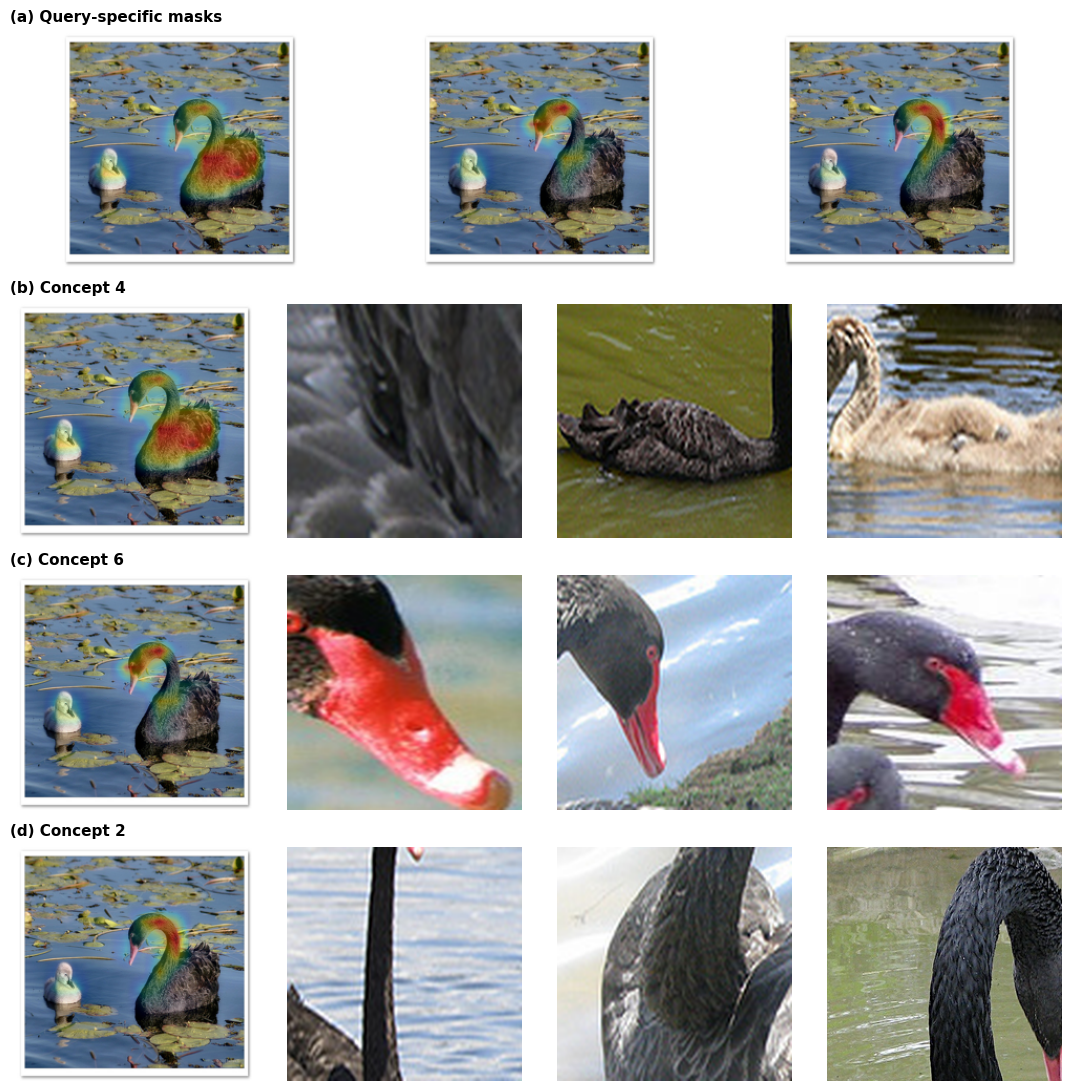

In [6]:
figure = plot_explanation(
    image,
    explanation,
    imagenet_root=IMAGENET,
    concept_ids=concept_ids,
)
plt.show()
plt.close(figure)